# Grad-CAM: What is the model looking at?

Gradient-weighted Class Activation Mapping (Grad-CAM) shows which parts of an image
the model focused on when making a prediction. The idea:

1. Forward pass -> get the predicted class score
2. Backpropagate that score to the **last conv layer** (where spatial structure is still intact)
3. Average the gradients across channels -> importance weight per feature map
4. Weighted sum of feature maps -> a coarse heatmap
5. Resize and overlay on the original image

For a spiral galaxy, the heatmap should light up the arms.
For an edge-on galaxy, it should highlight the elongated disk.
For a misclassified example, it often reveals the model was distracted by background noise or a nearby star.


In [1]:
import torch
import torch.nn as nn
from torchvision import transforms, models
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
import h5py
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASS_NAMES = ["Smooth", "Spiral", "Edge-on / Disturbed"]

## 1. Reload the data and model

In [2]:
remap = {2:0, 3:0, 4:0, 5:1, 6:1, 7:1, 0:2, 1:2, 8:2, 9:2}

with h5py.File("../data/Galaxy10_DECals.h5", "r") as f:
    X_all = f["images"][:]
    y_all = np.array([remap[l] for l in f["ans"][:]], dtype=np.int64)

_, X_test, _, y_test = train_test_split(
    X_all, y_all, test_size=0.15, stratify=y_all, random_state=42
)

print(f"Test set: {len(X_test)} images")

Test set: 2661 images


In [3]:
# load the saved ResNet - same architecture, only restore weights
resnet = models.resnet18(weights=None)
resnet.fc = nn.Linear(512, 3)
resnet.load_state_dict(torch.load("../checkpoints/resnet18_finetuned.pth", map_location=device))
resnet = resnet.to(device)
resnet.eval()
print("ResNet-18 loaded")

C:\Users\ashok\AppData\Local\Temp\ipykernel_23112\389672056.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  resnet.load_state_dict(torch.load("../checkpoints/resnet18_fi

ResNet-18 loaded


## 2. Grad-CAM implementation

We hook into `layer4` - the last residual block. At this point, the feature maps are
8×8 (for a 224×224 input), so each cell represents a 28×28 pixel region of the original image.
Earlier layers would give finer spatial resolution but less semantic meaning.


In [4]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model  = model
        self.grads  = None
        self.feats  = None

        # register hooks on the target layer
        target_layer.register_forward_hook(self._save_feats)
        target_layer.register_full_backward_hook(self._save_grads)

    def _save_feats(self, module, input, output):
        self.feats = output.detach()

    def _save_grads(self, module, grad_in, grad_out):
        self.grads = grad_out[0].detach()

    def __call__(self, img_tensor, class_idx=None):
        self.model.zero_grad()

        out = self.model(img_tensor)
        if class_idx is None:
            class_idx = out.argmax(dim=1).item()

        # backprop the score for the target class
        out[0, class_idx].backward()

        # global average pool the gradients → (C,)
        weights = self.grads[0].mean(dim=(1, 2))

        # weighted sum of feature maps → (H, W)
        cam = (weights[:, None, None] * self.feats[0]).sum(dim=0)
        cam = torch.relu(cam)

        # normalise to [0, 1]
        cam -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()

        return cam.cpu().numpy(), class_idx, out.softmax(dim=1)[0].detach().cpu().numpy()


gradcam = GradCAM(resnet, resnet.layer4)
print("GradCAM ready - hooked into resnet.layer4")

GradCAM ready - hooked into resnet.layer4


## 3. Helper: preprocess + overlay

In [5]:
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

def overlay_cam(img_np, cam, alpha=0.45):
    """Resize CAM to image size and overlay as a heatmap."""
    img_resized = np.array(Image.fromarray(img_np).resize((224, 224)))
    heatmap = Image.fromarray(np.uint8(255 * cam)).resize((224, 224), Image.BILINEAR)
    heatmap = np.array(heatmap) / 255.0
    coloured = cm.jet(heatmap)[..., :3]   # RGBA → RGB
    overlay  = (1 - alpha) * img_resized / 255.0 + alpha * coloured
    return np.clip(overlay, 0, 1)

def predict_single(img_np):
    """Run forward pass on one raw numpy image (256x256x3 uint8)."""
    img_pil    = Image.fromarray(img_np)
    img_tensor = preprocess(img_pil).unsqueeze(0).to(device)
    cam, pred_cls, probs = gradcam(img_tensor)
    return cam, pred_cls, probs

## 4. Correctly classified examples

One row per class - showing what the model focuses on when it gets things right.
Warm colours (red/yellow) = high attention. Cool colours (blue) = ignored.


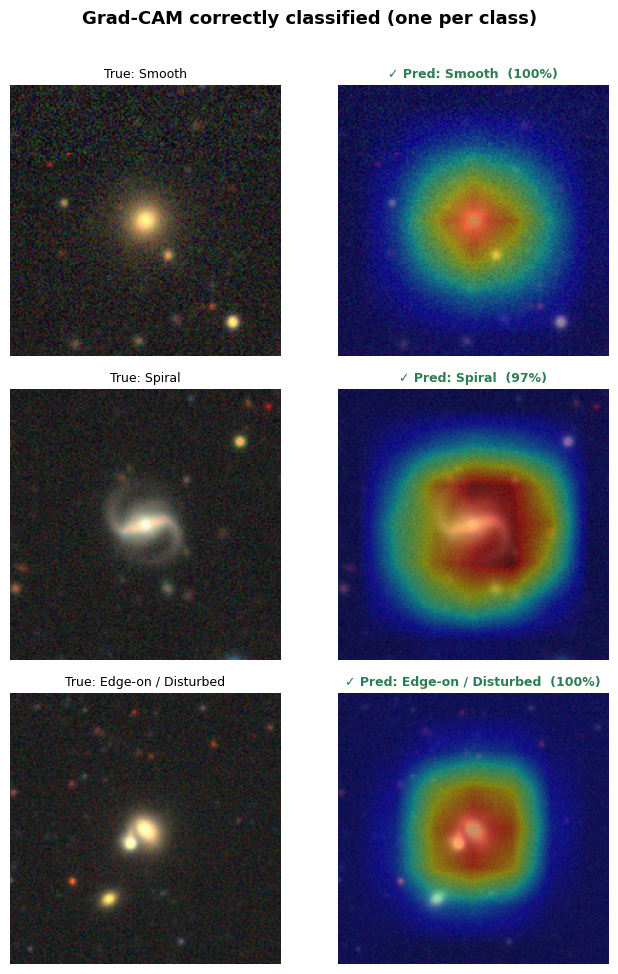

In [6]:
def show_gradcam_grid(indices, title, fname):
    n = len(indices)
    fig, axes = plt.subplots(n, 2, figsize=(7, n * 3.2))
    fig.suptitle(title, fontweight="bold", fontsize=13, y=1.01)

    if n == 1:
        axes = [axes]

    for ax_row, idx in zip(axes, indices):
        img_np  = X_test[idx]
        true_cls = y_test[idx]
        cam, pred_cls, probs = predict_single(img_np)

        # original
        ax_row[0].imshow(Image.fromarray(img_np).resize((224, 224)))
        ax_row[0].set_title(f"True: {CLASS_NAMES[true_cls]}", fontsize=9)
        ax_row[0].axis("off")

        # grad-cam overlay
        overlay = overlay_cam(img_np, cam)
        correct = pred_cls == true_cls
        color   = "#2E7D52" if correct else "#C0392B"
        status  = "✓" if correct else "✗"
        ax_row[1].imshow(overlay)
        ax_row[1].set_title(
            f"{status} Pred: {CLASS_NAMES[pred_cls]}  "
            f"({probs[pred_cls]*100:.0f}%)",
            fontsize=9, color=color, fontweight="bold"
        )
        ax_row[1].axis("off")

    plt.tight_layout()
    plt.savefig(f"../results/{fname}", bbox_inches="tight", dpi=150)
    plt.show()


# find one confident correct prediction per class
rng = np.random.default_rng(0)
correct_idxs = []
for cls in range(3):
    cls_idxs = np.where(y_test == cls)[0]
    for idx in rng.permutation(cls_idxs):
        cam, pred, probs = predict_single(X_test[idx])
        if pred == cls and probs[cls] > 0.85:
            correct_idxs.append(idx)
            break

show_gradcam_grid(correct_idxs,
                  "Grad-CAM correctly classified (one per class)",
                  "gradcam_correct.png")

## 5. Misclassified examples - the interesting ones

These are the cases where the model got it wrong.
Look at *where* the heatmap lands - often it's a bright star, image artefact,
or the outer halo rather than the galaxy morphology itself.

The edge-on -> smooth confusions are especially worth examining. An edge-on disk seen nearly face-on can project as a round, smooth shape -
the model isn't wrong to be uncertain, and the heatmap will show it grasping
at the central bulge rather than any disk structure.


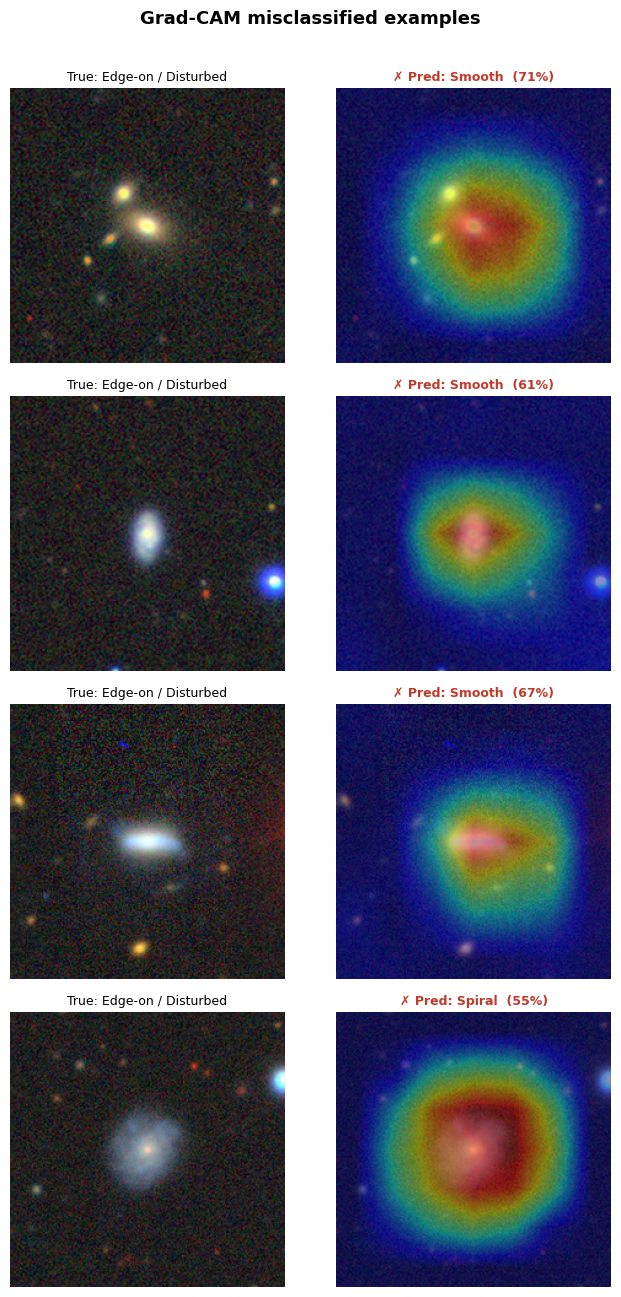

In [7]:
# find misclassified examples, prioritising edge-on predicted as smooth
wrong_idxs = []

# priority: edge-on (true=2) predicted as smooth (pred=0)
for idx in rng.permutation(np.where(y_test == 2)[0]):
    cam, pred, probs = predict_single(X_test[idx])
    if pred == 0:
        wrong_idxs.append(idx)
        if len(wrong_idxs) == 2:
            break

# fill the remaining with any other misclassification
for idx in rng.permutation(np.arange(len(y_test))):
    if len(wrong_idxs) == 4:
        break
    cam, pred, probs = predict_single(X_test[idx])
    if pred != y_test[idx] and idx not in wrong_idxs:
        wrong_idxs.append(idx)

show_gradcam_grid(wrong_idxs,
                  "Grad-CAM misclassified examples",
                  "gradcam_wrong.png")

## 6. Spiral arm attention - the astronomy insight

For spiral galaxies, does the model attend to the arms specifically?

Picking the 6 most confidently predicted spirals and checking.
If the heatmap traces the arms rather than just the central bulge,
that's morphological understanding, not just brightness heuristics.


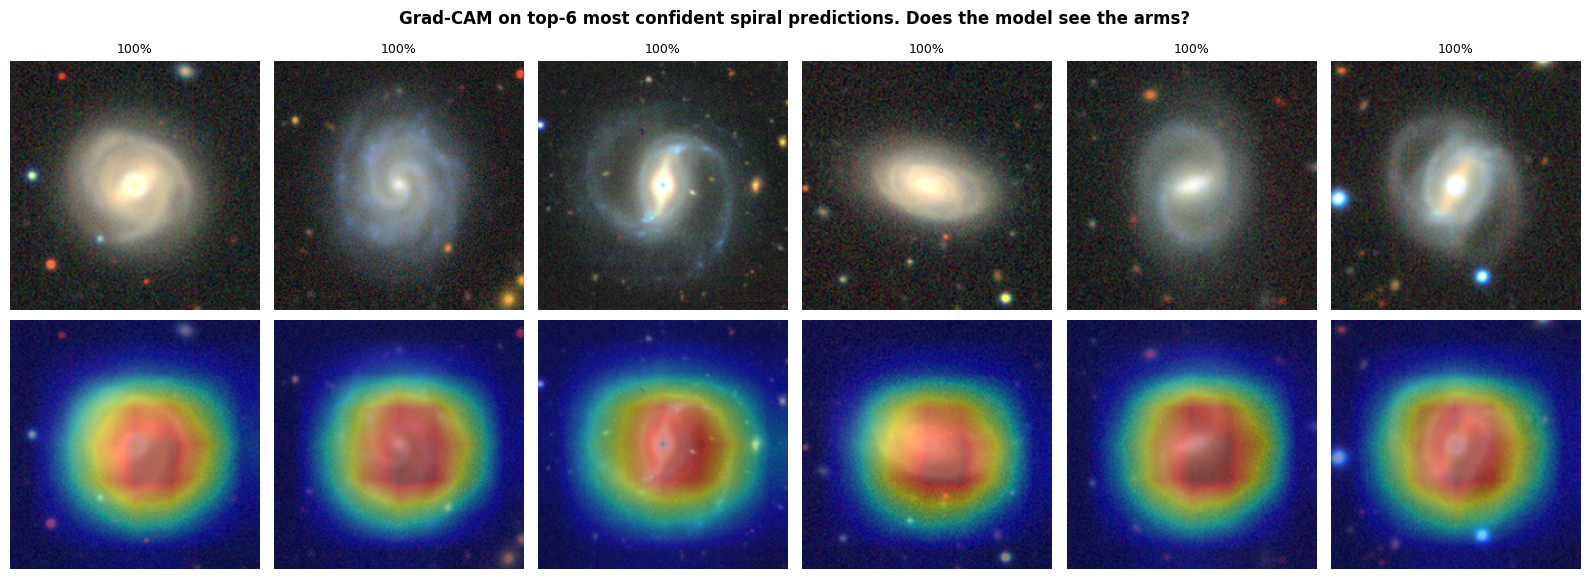

In [8]:
spiral_idxs = []
spiral_confs = []

for idx in np.where(y_test == 1)[0]:
    cam, pred, probs = predict_single(X_test[idx])
    if pred == 1:
        spiral_idxs.append(idx)
        spiral_confs.append(probs[1])

# top 6 most confident
top6 = np.argsort(spiral_confs)[-6:][::-1]
top_spiral_idxs = [spiral_idxs[i] for i in top6]

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle("Grad-CAM on top-6 most confident spiral predictions."
             " Does the model see the arms?", fontweight="bold")

for col, idx in enumerate(top_spiral_idxs):
    img_np = X_test[idx]
    cam, pred, probs = predict_single(img_np)

    axes[0, col].imshow(Image.fromarray(img_np).resize((224, 224)))
    axes[0, col].set_title(f"{probs[1]*100:.0f}%", fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].imshow(overlay_cam(img_np, cam))
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=9, fontweight="bold")
axes[1, 0].set_ylabel("Grad-CAM", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("../results/gradcam_spirals.png", bbox_inches="tight", dpi=150)
plt.show()

In [9]:
print("All Grad-CAM plots saved to results/")
print()
print("Files generated across the full project:")
import os
results = sorted(os.listdir("../results"))
for f in results:
    print(f"  {f}")
print()

All Grad-CAM plots saved to results/

Files generated across the full project:
  .ipynb_checkpoints
  brightness_by_class.png
  class_distribution.png
  cnn_confusion.png
  gradcam_correct.png
  gradcam_spirals.png
  gradcam_wrong.png
  mean_images.png
  mlp_confusion_matrix.png
  mlp_training_curves.png
  model_comparison_curves.png
  radial_profiles.png
  resnet_confusion.png
  sample_grid.png

